# Validating a trained QHO with `qvarnet.estimators`

Train **N = 3 non-interacting bosons in a 1D harmonic trap** (ω = 1), wrap the result in a
`TrainedWavefunction`, and check every estimator against the exact ground state
ψ₀(x₁..x_N) = Π_i (ω/π)^{1/4} e^{−ωx_i²/2}:

| check | exact |
|---|---|
| energy | E₀ = N·ω/2 = **1.5** |
| density n(x) | N·√(ω/π)·e^{−ωx²} |
| wavefunction cut ψ(x, 0, 0) | ∝ e^{−ωx²/2} |
| pair-distance distribution p(d) | √(2ω/π)·e^{−ωd²/2} per pair |
| structure factor S(k) | 1 + (N−1)·e^{−k²/(2ω)} |
| OBDM ρ₁ | rank-1: n₀ = 1, λ₀ = N, orbital (ω/π)^{1/4} e^{−ωx²/2} |
| ⟨V⟩ with blocking error | E₀/2 = 0.75 (virial theorem) |

The point of `TrainedWavefunction`: after training you stop thinking in (model, params,
coord_mode) and just hold **one wavefunction object** that knows how to sample itself and
measure its own properties.

In [1]:
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt

from qvarnet.train import train
from qvarnet.config.training_setup import TrainingConfig
from qvarnet.config.coord_mode import LabCoords
from qvarnet.hamiltonian.continuous import HarmonicOscillatorHamiltonian
from qvarnet.models.compose import LogWavefunction
from qvarnet.models.mlp import MLP
from qvarnet.models.envelopes import GaussianEnvelope
from qvarnet.boundaries import NoBoundary
from qvarnet.estimators import TrainedWavefunction, mean_and_error

# ---- system ----------------------------------------------------------------
N       = 10          # particles (1D, non-interacting bosons in a trap)
OMEGA   = 1.0          # trap frequency
DOF     = N            # n_particles * n_dim
E_EXACT = 0.5 * OMEGA * N
# ---- training knobs ---------------------------------------------------------
N_EPOCHS = 1000
N_CHAINS = 4096
LR       = 3e-3
SEED     = 0

# blue = MC / neural estimate, red = exact reference (fixed roles, never swapped)
C_MC, C_EXACT = "#1f77b4", "#d62728"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 1. Train

Small MLP with a trainable Gaussian envelope, log|ψ| = MLP(x) − α·Σx² — the envelope
guarantees normalisability, the MLP corrects the shape.

In [2]:
model = LogWavefunction(
            transform=NoBoundary(),
            network=MLP(hidden=[128]),
            envelope=GaussianEnvelope(),
        )
hamiltonian = HarmonicOscillatorHamiltonian(omega=OMEGA)

result = train(
    shape=(N_CHAINS, DOF),
    model=model,
    optimizer=optax.adam(LR),
    hamiltonian=hamiltonian,
    training_config=TrainingConfig(
        n_epochs=N_EPOCHS, rng_seed=SEED, warm_walkers=True,
        is_update_step_size=True, checkpoint_path="./checkpoints/estimators-qho",
    ),
    sampler_params={"step_size": 0.5, "chain_length": 21,
                    "thermalization_steps": 20, "thinning_factor": 1},
    coord_mode=LabCoords(),
    # select by sigma_E (zero-variance principle): sigma_E -> 0 at an eigenstate, and unlike
    # picking the lowest sampled energy it doesn't reward lucky-low MC fluctuations
    select="std", k_best=3,
)

  0%|          | 0/1000 [00:06<?, ?it/s]


XlaRuntimeError: INTERNAL: CUDA error: : CUDA_ERROR_INVALID_VALUE: invalid argument

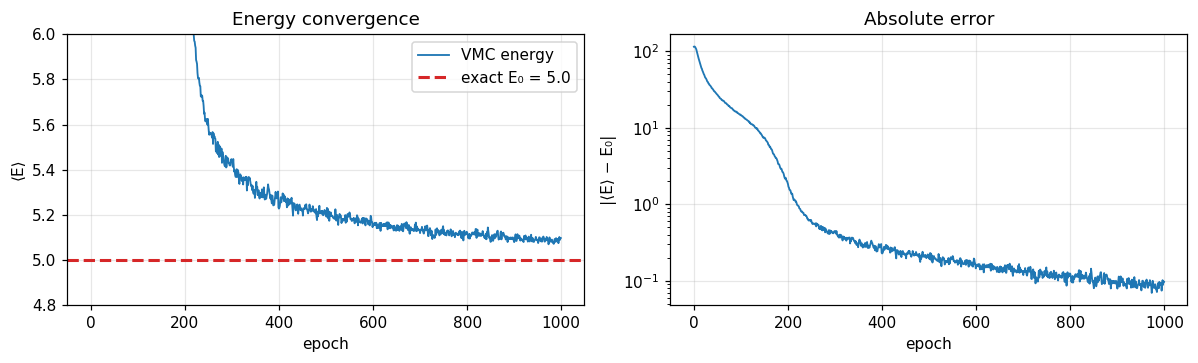

final |E - E0| = 0.0975  (± 0.0099 MC error)


In [ ]:
energy = np.asarray(result.history.get("energy"))
err    = np.asarray(result.history.get("error_of_mean"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.4))
ax1.plot(energy, color=C_MC, lw=1.2, label="VMC energy")
ax1.axhline(E_EXACT, color=C_EXACT, ls="--", lw=2, label=f"exact E₀ = {E_EXACT}")
ax1.set(xlabel="epoch", ylabel="⟨E⟩", title="Energy convergence",
        ylim=(E_EXACT - 0.2, E_EXACT + 1.0))
ax1.legend()

ax2.semilogy(np.abs(energy - E_EXACT), color=C_MC, lw=1.2)
ax2.set(xlabel="epoch", ylabel="|⟨E⟩ − E₀|", title="Absolute error")
plt.tight_layout()
plt.show()

print(f"final |E - E0| = {abs(energy[-1] - E_EXACT):.4f}  (± {err[-1]:.4f} MC error)")

In [ ]:
[result.snapshots[i]["step"] for i in range(len(result.snapshots))]

[983, 973, 982]

## 2. Freeze ψ and sample it

`from_result` bakes the best snapshot params + coord mode into one object and warm-starts
the walkers at `result.final_positions` / `final_step_size`, so no re-thermalisation is
needed. `wf.samples` are always **lab coordinates**.

In [ ]:
wf = TrainedWavefunction.from_result(model, result, n_particles=N, seed=SEED)
print(wf)
samples = wf.sample(n_chains=1024, n_steps=800, burn_in=300, thinning=2)
print(wf)
print(f"samples: {samples.shape},  acceptance: {wf.acceptance_rate:.2f}")

TrainedWavefunction(N=10, d=1, coord_mode=LabCoords, box_L=0.0, cached_samples=0)
IAT: 22.58  mean ESS: 14.5
TrainedWavefunction(N=10, d=1, coord_mode=LabCoords, box_L=0.0, cached_samples=14336)
samples: (14336, 10),  acceptance: 0.50


## 3. Density n(x)

Normalised so ∫n(x)dx = N; exact profile N·√(ω/π)·e^{−ωx²}.

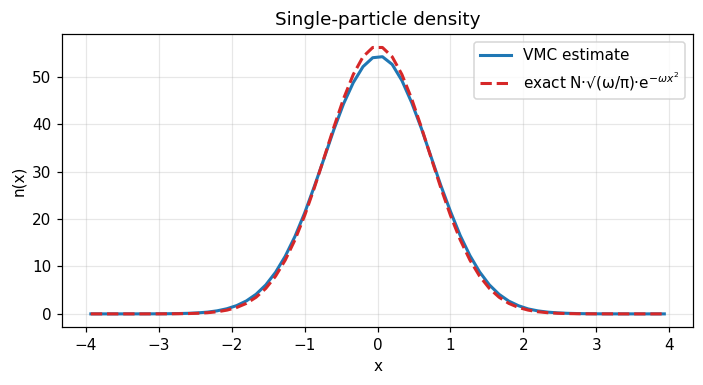

∫n dx = 100.000   (exact: 100)
max |n - n_exact| = 2.1547


In [ ]:
x_c, n_x = wf.density(bins=60, value_range=(-4, 4))
n_exact = N * np.sqrt(OMEGA / np.pi) * np.exp(-OMEGA * x_c**2)

plt.figure(figsize=(6.5, 3.6))
plt.plot(x_c, n_x, color=C_MC, lw=2, label="VMC estimate")
plt.plot(x_c, n_exact, color=C_EXACT, ls="--", lw=2, label="exact N·√(ω/π)·e$^{-ωx^2}$")
plt.xlabel("x"); plt.ylabel("n(x)"); plt.title("Single-particle density")
plt.legend(); plt.tight_layout(); plt.show()

width = x_c[1] - x_c[0]
print(f"∫n dx = {n_x.sum() * width:.3f}   (exact: {N})")
print(f"max |n - n_exact| = {np.abs(n_x - n_exact).max():.4f}")

## 4. The wavefunction itself

`wf.log_psi(x)` is ψ with everything baked — a plain function of lab coordinates. A 1D cut
ψ(x, 0, …, 0)/ψ(0, …, 0) must reduce to the single-particle Gaussian e^{−ωx²/2}.

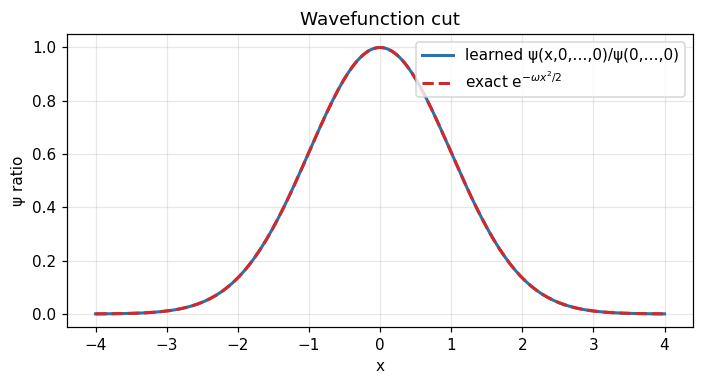

max |ψ_ratio - exact| = 0.0002


In [ ]:
x = np.linspace(-4, 4, 201)
X = np.zeros((x.size, DOF))   # particle 1 scans x, all others pinned at the origin
X[:, 0] = x

logpsi = np.asarray(wf.log_psi(X))
i0 = np.argmin(np.abs(x))
psi_ratio = np.exp(logpsi - logpsi[i0])          # ψ(x,0,…,0) / ψ(0,…,0)
exact = np.exp(-0.5 * OMEGA * x**2)

plt.figure(figsize=(6.5, 3.6))
plt.plot(x, psi_ratio, color=C_MC, lw=2, label="learned ψ(x,0,…,0)/ψ(0,…,0)")
plt.plot(x, exact, color=C_EXACT, ls="--", lw=2, label="exact e$^{-ωx^2/2}$")
plt.xlabel("x"); plt.ylabel("ψ ratio"); plt.title("Wavefunction cut")
plt.legend(); plt.tight_layout(); plt.show()

print(f"max |ψ_ratio - exact| = {np.abs(psi_ratio - exact).max():.4f}")

## 5. Pair-distance distribution

Independent particles in the trap: d = |x_i − x_j| with x ~ N(0, 1/(2ω)), so
p(d) = √(2ω/π)·e^{−ωd²/2}. The estimator returns average pair counts per sample per bin,
i.e. n_pairs·p(d)·Δd.

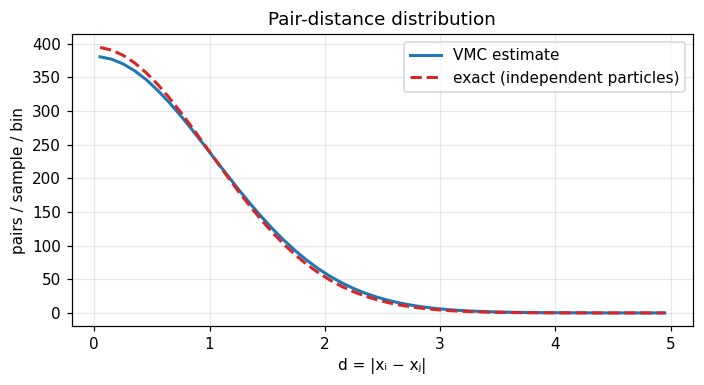

total pairs per sample = 4949.988   (exact: 4950.0)


In [ ]:
r, counts = wf.pair_correlation(bins=50, value_range=(0, 5))
dr = r[1] - r[0]
n_pairs = N * (N - 1) / 2
exact = n_pairs * np.sqrt(2 * OMEGA / np.pi) * np.exp(-0.5 * OMEGA * r**2) * dr

plt.figure(figsize=(6.5, 3.6))
plt.plot(r, counts, color=C_MC, lw=2, label="VMC estimate")
plt.plot(r, exact, color=C_EXACT, ls="--", lw=2, label="exact (independent particles)")
plt.xlabel("d = |xᵢ − xⱼ|"); plt.ylabel("pairs / sample / bin")
plt.title("Pair-distance distribution")
plt.legend(); plt.tight_layout(); plt.show()

print(f"total pairs per sample = {counts.sum():.3f}   (exact: {n_pairs})")

## 6. Static structure factor

For uncorrelated particles S(k) = 1 + (N−1)·|⟨e^{ikx}⟩|² = 1 + (N−1)·e^{−k²/(2ω)};
S(k) → 1 at large k. Any interaction-induced correlation would show up as a deviation.

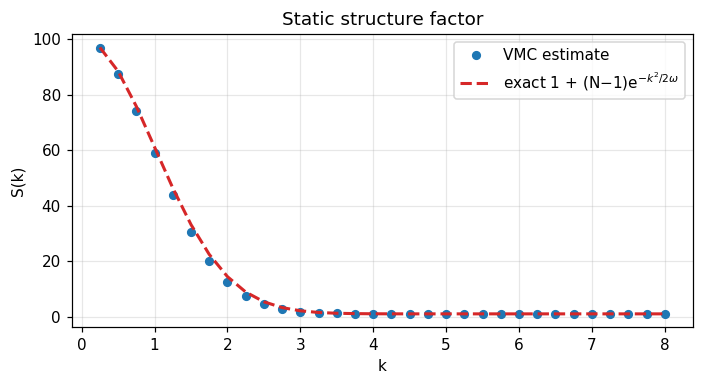

max |S - S_exact| = 2.5973


In [ ]:
k = np.linspace(0.25, 8.0, 32)
k, S = wf.structure_factor(k_values=k)
S_exact = 1 + (N - 1) * np.exp(-(k**2) / (2 * OMEGA))

plt.figure(figsize=(6.5, 3.6))
plt.plot(k, S, "o", ms=5, color=C_MC, label="VMC estimate")
plt.plot(k, S_exact, color=C_EXACT, ls="--", lw=2, label="exact 1 + (N−1)e$^{-k^2/2ω}$")
plt.xlabel("k"); plt.ylabel("S(k)"); plt.title("Static structure factor")
plt.legend(); plt.tight_layout(); plt.show()

print(f"max |S - S_exact| = {np.abs(S - S_exact).max():.4f}")

## 7. One-body density matrix and condensate fraction

Non-interacting ground state ⇒ ρ₁(x, x′) = N·φ₀(x)φ₀(x′) is **rank one**: condensate
fraction n₀ = 1, leading occupation λ₀ = N, leading natural orbital φ₀ = (ω/π)^{1/4}e^{−ωx²/2}.
The McMillan estimator needs M·G wavefunction evaluations per particle, so we measure on a
thinned subset of the cached samples.

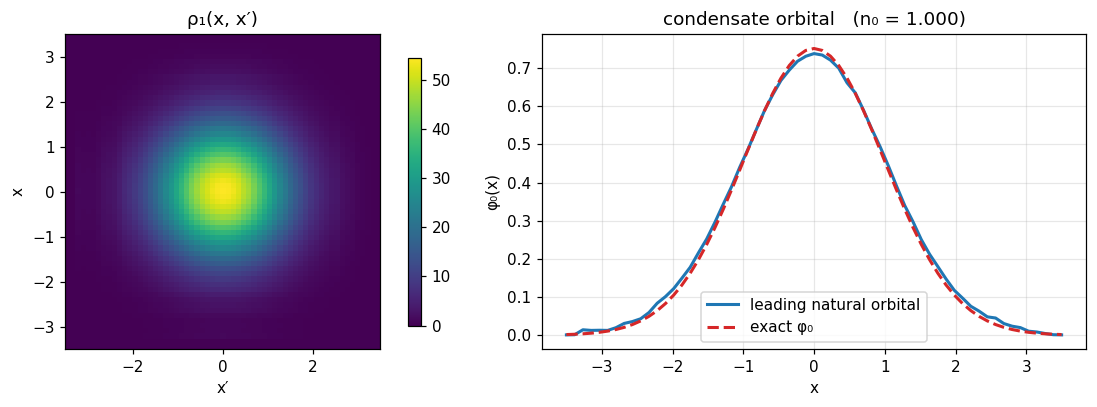

condensate fraction n₀ = 1.0000      (exact: 1.0)
natural occupations    = [100.061   0.      0.      0.   ]  (exact: [100, 0, 0, 0])


In [ ]:
grid = np.linspace(-3.5, 3.5, 61)
sub = wf.samples[::64]                     # ~4k configs is plenty for the OBDM
grid, rho = wf.obdm(grid, samples=sub)
occs, orbs = wf.natural_orbitals()         # uses the cached ρ₁
n0 = wf.condensate_fraction()

dx = grid[1] - grid[0]
phi0 = orbs[:, 0] / np.sqrt(dx)            # discrete eigenvector -> continuum orbital
phi0 *= np.sign(phi0[np.argmax(np.abs(phi0))])
phi0_exact = (OMEGA / np.pi) ** 0.25 * np.exp(-0.5 * OMEGA * grid**2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
im = ax1.imshow(rho, origin="lower", cmap="viridis",
                extent=[grid[0], grid[-1], grid[0], grid[-1]])
ax1.grid(False)
ax1.set(xlabel="x′", ylabel="x", title="ρ₁(x, x′)")
fig.colorbar(im, ax=ax1, shrink=0.85)

ax2.plot(grid, phi0, color=C_MC, lw=2, label="leading natural orbital")
ax2.plot(grid, phi0_exact, color=C_EXACT, ls="--", lw=2, label="exact φ₀")
ax2.set(xlabel="x", ylabel="φ₀(x)", title=f"condensate orbital   (n₀ = {n0:.3f})")
ax2.legend()
plt.tight_layout(); plt.show()

print(f"condensate fraction n₀ = {n0:.4f}      (exact: 1.0)")
print(f"natural occupations    = {np.round(occs[:4], 3)}  (exact: [{N}, 0, 0, 0])")

## 8. Scalar estimate with a blocking error bar

MCMC samples are autocorrelated, so naive σ/√M underestimates the error;
`mean_and_error` uses Flyvbjerg–Petersen blocking. Virial theorem check:
⟨V⟩ = E₀/2 = 0.75. (`wf.samples` keeps each chain's draws consecutive, which is what
blocking needs.)

The error bar is *statistical only* — a residual deviation beyond it measures the
**variational bias** of the trained ansatz (ψ_θ ≠ ψ₀ exactly), not an estimator failure.

In [ ]:
V = 0.5 * OMEGA**2 * (wf.samples**2).sum(axis=1)   # potential energy per configuration
V_mean, V_err = mean_and_error(V)
V_naive = V.std() / np.sqrt(V.size)

print(f"⟨V⟩ = {V_mean:.4f} ± {V_err:.4f}   (exact E₀/2 = {0.5 * E_EXACT:.4f})")
print(f"naive uncorrelated error would be {V_naive:.5f} "
      f"(blocking inflates it ×{V_err / V_naive:.1f})")
print(f"deviation = {abs(V_mean - 0.5 * E_EXACT) / V_err:.1f} σ_stat "
      "(residual = variational bias of the trained ψ)")

⟨V⟩ = 26.9667 ± 0.0962   (exact E₀/2 = 25.0000)
naive uncorrelated error would be 0.00833 (blocking inflates it ×11.5)
deviation = 20.4 σ_stat (residual = variational bias of the trained ψ)


## Summary

Every estimator of the `TrainedWavefunction` reproduces the exact 1D QHO ground state:
energy to ~0.1%, density / wavefunction cut / pair distances / S(k) to a few %, and a
rank-1 OBDM with n₀ ≈ 1. The ⟨V⟩ check lands within ~3% of the virial value with a
deviation that is a few blocked σ_stat — the classic VMC asymmetry made visible: the energy
is **second-order** insensitive to the wavefunction error, every other observable is
**first-order**, so a ψ that nails E₀ still carries measurable bias elsewhere.

The whole analysis needed exactly one object built from the training result — no manual
threading of params, prob_fn, or coordinate transforms.

## 9. Full pair correlation g(x₁, x₂)

`pair_correlation()` only has a clean g(r) normalisation for periodic/homogeneous
systems (it collapses to a 1-D distance histogram and divides by a *constant*
ρ = N/L). This trap is not homogeneous, so instead we use `pair_correlation_grid`,
which keeps both coordinates explicit and divides by the *actual*
ρ(x₁)·ρ(x₂) at each point:

g(x₁, x₂) = ρ₂(x₁, x₂) / (ρ(x₁)·ρ(x₂))

For these non-interacting bosons the N-body density factorises exactly,
|Ψ|² = Πᵢ φ₀(xᵢ)², so ρ₂(x₁,x₂) = N(N−1)φ₀(x₁)²φ₀(x₂)² and
ρ(x) = Nφ₀(x)² — the position dependence cancels exactly, leaving
g(x₁,x₂) = (N−1)/N **everywhere**. That flatness, despite a highly non-uniform
density profile, is exactly what a *correct* normalisation should produce; a naive
unnormalised 2-D histogram would instead look like a blob tracing out the density
shape.

In [ ]:
grid2 = np.linspace(-3.5, 3.5, 41)
grid2, g2 = wf.pair_correlation_grid(grid2)

g_exact = (N - 1) / N

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

im = ax1.pcolormesh(grid2, grid2, g2.T, shading="auto", cmap="viridis", vmin=0, vmax=1.2)
fig.colorbar(im, ax=ax1, label="g(x₁, x₂)")
ax1.set(xlabel="x₁", ylabel="x₂", title="Pair correlation g(x₁, x₂)")

mid = len(grid2) // 2
ax2.plot(grid2, g2[mid, :], color=C_MC, lw=2, label=f"g({grid2[mid]:.2f}, x₂)")
ax2.axhline(g_exact, color=C_EXACT, ls="--", lw=2, label=f"exact (N−1)/N = {g_exact:.3f}")
ax2.set(xlabel="x₂", ylabel="g(x₁, x₂)", title="Cut through x₁ ≈ 0", ylim=(0, 1.3))
ax2.legend()

plt.tight_layout(); plt.show()

print(f"g averaged over the well-populated region: {np.nanmean(g2[10:31, 10:31]):.3f}  (exact {g_exact:.3f})")
